In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import plotly.express as px

import torch, torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from torchvision import transforms
from sklearn.model_selection import train_test_split


import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms

from PIL import Image
from tqdm import tqdm


In [2]:
# Folder where data lies
base_path = 'data/Processed_Data'
data = []

folder_to_class_map = {
    "Cladocera": "Cladocera",
    "Rotifer": "Rotifer",
    "Copepoda": "Copepoda",
    "Bubbles": "Bubble",
    "Exoskeleton": "Exoskeleton",
    "Fiber_Hairlike": "Fiber",
    "Fiber_Squiggly": "Fiber",
    "Plant_Matter": "Plant_Matter",
    "Bosminidae": "Bosmina",
    "Daphnia": "Daphnia",
    "Nauplius_Copepod": "Nauplius",
    "Cyclopoid": "Cyclopoid",
    "Harpacticoid": "Harpacticoid",
    "Calanoid": "Calanoid"
}

# Walking through the directory structure
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.tif'):
            raw_folder_name = os.path.basename(root)
            
            # Translating the folder name using folder_to_class_map
            # If a folder isn't in the map, it keeps its raw name
            mapped_class_name = folder_to_class_map.get(raw_folder_name, raw_folder_name)
            
            data.append({
                'OriginalFolder': raw_folder_name, 
                'FolderName': mapped_class_name, 
                'FileName': file
            })

df = pd.DataFrame(data)

In [3]:
df

,OriginalFolder,FolderName,FileName
0,Partial_Copepod,Partial_Copepod,20240430_Erie_WNS0904_2mm_Rep1_000023_4.tif
1,Partial_Copepod,Partial_Copepod,20240430_Erie_WNS0904_2mm_Rep1_000003_1.tif
2,Partial_Copepod,Partial_Copepod,20240514_Erie_WNS096_2mm_Rep1_000014_1.tif
3,Partial_Copepod,Partial_Copepod,20240430_Erie_WNS0904_2mm_Rep5_000016_2.tif
4,Partial_Copepod,Partial_Copepod,20240430_Erie_WNS0904_2mm_Rep4_000010_2.tif
...,...,...,...
57091,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep4_000013_50.tif
57092,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep4_000014_65.tif
57093,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep2_000008_42.tif
57094,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep1_000018_95.tif


In [4]:
print(f"Number of unique folders: {df["FolderName"].nunique()}")

Number of unique folders: 32


In [5]:
# Checking file count per folder

df_counts = df.groupby("FolderName", as_index = False).agg(
    file_count = ("FileName", "count")
)

df_counts

,FolderName,file_count
0,149um>,12073
1,Bosmina,2912
2,Brachionidae,3
3,Bubble,38
4,Calanoid,416
5,Cladocera,776
6,Conochilus,34
7,Copepoda,455
8,Cyclopoid,1362
9,Daphnia,2401


In [6]:
# Map which shows the hierarchy, separated using "_"
# Map is created by the hierarchy described in the "updated_flowchart.pdf" shared by Dr. Sofia.

hier_map = {
    "Cladocera": "Zooplankton",
    "Rotifer": "Zooplankton",
    "Copepoda": "Zooplankton",
    
    "Bubble": "Not-Zooplankton",
    "Exoskeleton": "Not-Zooplankton",
    "Fiber": "Not-Zooplankton",
    "Plant_Matter": "Not-Zooplankton",
    
    "Bosmina": "Cladocera_Zooplankton",
    "Daphnia": "Cladocera_Zooplankton",
    
    "Nauplius": "Copepoda_Zooplankton",
    "Cyclopoid": "Copepoda_Zooplankton",
    "Harpacticoid": "Copepoda_Zooplankton",
    "Calanoid": "Copepoda_Zooplankton",
}

In [7]:
def parse_hierarchy(folder_name):
    """Parses the dictionary to return Level 0, Level 1, and Level 2 labels.

    Args:
        folder_name (str): The name of the folder containing the images.

    Returns:
        tuple: A tuple containing three elements:
            1. str: The Level 0 target.
            2. str: The Level 1 target. Returns 'Unknown' if not applicable.
            3. str: The Level 2 target. Returns 'Unknown' if not applicable.
            
            Returns (None, None, None) if the folder_name is not in the hierarchy.
    """
    
    # Checking if the folder is one of our root nodes directly
    if folder_name in ["Zooplankton", "Not-Zooplankton"]:
        return folder_name, "Unknown", "Unknown"
        
    # If the folder is not in our map at all, marking for deletion
    if folder_name not in hier_map:
        return None, None, None
        
    parent_string = hier_map[folder_name]
    parts = parent_string.split("_")
    
    if len(parts) == 1:
        # It is a Level 1 node
        return parts[0], folder_name, "Unknown"
        
    elif len(parts) == 2:
        # It is a Level 2 node
        return parts[1], parts[0], folder_name

In [8]:

# Applying the parsing function
parsed_levels = df['FolderName'].apply(lambda x: pd.Series(parse_hierarchy(x)))
df[['Target_L0', 'Target_L1', 'Target_L2']] = parsed_levels


# Droping all rows that are not part of the defined hierarchy
df_cleaned = df.dropna(subset=['Target_L0']).reset_index(drop=True)

In [9]:
df_cleaned[['OriginalFolder', 'FolderName', 'FileName', 'Target_L0', 'Target_L1', 'Target_L2']]

,OriginalFolder,FolderName,FileName,Target_L0,Target_L1,Target_L2
0,Cyclopoid,Cyclopoid,20240430_Erie_WNS0904_2mm_Rep1_000022_211.tif,Zooplankton,Copepoda,Cyclopoid
1,Cyclopoid,Cyclopoid,20240430_Erie_WNS0904_2mm_Rep4_000014_128.tif,Zooplankton,Copepoda,Cyclopoid
2,Cyclopoid,Cyclopoid,20240430_Erie_WNS0904_2mm_Rep5_000020_188.tif,Zooplankton,Copepoda,Cyclopoid
3,Cyclopoid,Cyclopoid,20240430_Erie_WNS0904_2mm_Rep2_000008_73.tif,Zooplankton,Copepoda,Cyclopoid
4,Cyclopoid,Cyclopoid,20240430_Erie_WNS0904_2mm_Rep1_000001_2.tif,Zooplankton,Copepoda,Cyclopoid
...,...,...,...,...,...,...
28559,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep4_000014_59.tif,Not-Zooplankton,Plant_Matter,Unknown
28560,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep4_000013_50.tif,Not-Zooplankton,Plant_Matter,Unknown
28561,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep4_000014_65.tif,Not-Zooplankton,Plant_Matter,Unknown
28562,Plant_Matter,Plant_Matter,20240430_Erie_WNS0904_2mm_Rep2_000008_42.tif,Not-Zooplankton,Plant_Matter,Unknown


In [10]:
# Dropping any rows where Level 1 is 'Unknown'

df_cleaned = df_cleaned[df_cleaned['Target_L1'] != 'Unknown'].reset_index(drop=True)

In [11]:
import plotly.io as pio
pio.renderers.default = "iframe"


fig = px.sunburst(
    df_cleaned, 
    path=['Target_L0', 'Target_L1', 'Target_L2'], 
    title="Zooplankton Hierarchical Distribution",
    color='Target_L0',
    color_discrete_map={'Zooplankton': '#4c78a8', 'Not-Zooplankton': '#e45756', 'Unknown': '#d3d3d3'}
)

fig.update_traces(textinfo="label+percent entry")
fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

In [12]:
df_cleaned[df_cleaned.FolderName.isin(hier_map.keys())].groupby("FolderName", as_index = False).agg(
    file_count = ("FileName", "count")
)

,FolderName,file_count
0,Bosmina,2912
1,Bubble,38
2,Calanoid,416
3,Cladocera,776
4,Copepoda,455
5,Cyclopoid,1362
6,Daphnia,2401
7,Exoskeleton,1123
8,Fiber,11743
9,Harpacticoid,15


In [13]:
# Defining the numerical mappings for each hierarchical level.

LEVEL_0_MAP = {
    "Not-Zooplankton": 0, 
    "Zooplankton": 1
}

LEVEL_1_MAP = {
    "Cladocera": 0, 
    "Rotifer": 1, 
    "Copepoda": 2, 
    "Bubble": 3, 
    "Exoskeleton": 4, 
    "Fiber": 5, 
    "Plant_Matter": 6,
    "Unknown": -1
}

LEVEL_2_MAP = {
    "Bosmina": 0, 
    "Daphnia": 1, 
    "Nauplius": 2, 
    "Cyclopoid": 3, 
    "Harpacticoid": 4, 
    "Calanoid": 5, 
    "Unknown": -1
}

In [60]:
REVERSE_L0_MAP = {value:(key if value != -1 else "Terminal Parent or Unknown") for key,value in LEVEL_0_MAP.items()}

REVERSE_L1_MAP = {value:(key if value != -1 else "Terminal Parent or Unknown") for key,value in LEVEL_1_MAP.items()}

REVERSE_L2_MAP = {value:(key if value != -1 else "Terminal Parent or Unknown") for key,value in LEVEL_2_MAP.items()}
REVERSE_L2_MAP

{0: 'Bosmina',
 1: 'Daphnia',
 2: 'Nauplius',
 3: 'Cyclopoid',
 4: 'Harpacticoid',
 5: 'Calanoid',
 -1: 'Terminal Parent or Unknown'}

In [14]:
class HierarchicalZooplanktonDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        """ 
            Returns length of the dataset
        """
        return len(self.dataframe)

    def __getitem__(self, idx):
        """Retrieves an image and its corresponding hierarchical labels by index.

        Args:
            idx (int): The index of the sample to fetch.

        Returns:
            tuple: A tuple containing the transformed image tensor and a dictionary 
                   of three target tensors ('L0', 'L1', 'L2').
        """
        if torch.is_tensor(idx):
            idx = idx.tolist()

        folder_name = self.dataframe.iloc[idx]['OriginalFolder']
        file_name = self.dataframe.iloc[idx]['FileName']
        img_path = os.path.join(self.root_dir, folder_name, file_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        l0_str = self.dataframe.iloc[idx]['Target_L0']
        l1_str = self.dataframe.iloc[idx]['Target_L1']
        l2_str = self.dataframe.iloc[idx]['Target_L2']

        targets = {
            'L0': torch.tensor(LEVEL_0_MAP[l0_str], dtype=torch.long),
            'L1': torch.tensor(LEVEL_1_MAP[l1_str], dtype=torch.long),
            'L2': torch.tensor(LEVEL_2_MAP[l2_str], dtype=torch.long)
        }

        return image, targets

In [15]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("=== TESTING DATASET & DATALOADER ===")

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

ROOT_DIR = "data/Processed_Data" 

# Initialize dataset
dummy_dataset = HierarchicalZooplanktonDataset(
    dataframe=df_cleaned, 
    root_dir=ROOT_DIR, 
    transform=basic_transform
)

# Initialize DataLoader
dummy_loader = DataLoader(
    dummy_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0,
    pin_memory=False
)

# Fetch a single batch
images, targets = next(iter(dummy_loader))

print("Batch Tensor Shapes:")
print(f"Images shape: {images.shape}")
print(f"Target L0 shape: {targets['L0'].shape}")
print(f"Target L1 shape: {targets['L1'].shape}")
print(f"Target L2 shape: {targets['L2'].shape}\n")

=== TESTING DATASET & DATALOADER ===
Batch Tensor Shapes:
Images shape: torch.Size([32, 3, 224, 224])
Target L0 shape: torch.Size([32])
Target L1 shape: torch.Size([32])
Target L2 shape: torch.Size([32])



In [16]:
# Defining transformations. Adding augmentations for the training set.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [17]:
# Performing Train (70%), Test (15%), Val (15%) Split

df_train, df_temp = train_test_split(df_cleaned, test_size=0.30, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

In [18]:
# Reseting indices to ensure the PyTorch Dataset class can fetch rows correctly by index

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [19]:
print(f"Training samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")
print(f"Testing samples: {len(df_test)}\n")

Training samples: 19991
Validation samples: 4284
Testing samples: 4284



In [20]:
ROOT_DIR = "data/Processed_Data" 

train_dataset = HierarchicalZooplanktonDataset(dataframe=df_train, root_dir=ROOT_DIR, transform=train_transform)
val_dataset = HierarchicalZooplanktonDataset(dataframe=df_val, root_dir=ROOT_DIR, transform=val_transform)
test_dataset = HierarchicalZooplanktonDataset(dataframe=df_test, root_dir=ROOT_DIR, transform=val_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,
    num_workers=0, 
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False
)

In [21]:
# Setting device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [22]:
def calculate_class_weights(df, target_col, num_classes, level_map):
    """Calculates inverse frequency weights to handle class imbalance.

    This function computes weights for each class inversely proportional 
    to their frequency in the training set. It explicitly ignores the '-1' 
    label used for terminal nodes. If a valid class has zero samples in 
    the current split, it assigns a default count of 1 to prevent 
    division by zero errors.

    Args:
        df (pd.DataFrame): The training dataframe containing the target labels.
        target_col (str): The name of the column containing the target strings 
                          (e.g., 'Target_L0', 'Target_L1', 'Target_L2').
        num_classes (int): The total number of valid classes expected for this level.
        level_map (dict): The dictionary mapping string labels to integers.

    Returns:
        torch.Tensor: A float32 tensor containing the computed class weights.
    """
    # Mapping the string labels in the dataframe to their corresponding integers
    mapped_series = df[target_col].map(level_map)
    
    # Counting the occurrences, filtering out the -1 "Unknown" index
    class_counts = mapped_series[mapped_series != -1].value_counts().sort_index()
    
    # Safely get the count for integer classes 0 through num_classes
    counts = np.array([class_counts.get(i, 1) for i in range(num_classes)])
    
    # Calculate inverse frequencies
    total_samples = counts.sum()
    weights = total_samples / (num_classes * counts)
    
    return torch.tensor(weights, dtype=torch.float32)

# Calculating weights based on the training data by passing the mapping dicts
weights_l0 = calculate_class_weights(df_train, 'Target_L0', 2, LEVEL_0_MAP).to(device)
weights_l1 = calculate_class_weights(df_train, 'Target_L1', 7, LEVEL_1_MAP).to(device)
weights_l2 = calculate_class_weights(df_train, 'Target_L2', 6, LEVEL_2_MAP).to(device)

print(weights_l0)
print(weights_l1)
print(weights_l2)

tensor([1.0639, 0.9433], device='mps:0')
tensor([  0.6685,   1.9736,   0.5856, 105.7725,   3.6473,   0.3483,   7.4178],
       device='mps:0')
tensor([  0.6714,   0.8246,   0.4198,   1.4215, 125.8636,   4.8922],
       device='mps:0')


In [23]:
class HierarchicalZooplanktonViT(nn.Module):
    """
        A vision transformer with multi head.
        This model uses a pre trained ViT backbone to extract visual features 
        from zooplankton images. It then splits into three independent linear 
        classification heads corresponding to the three levels of the taxonomy.
    """

    def __init__(self, pretrained=True, freeze_backbone=True):

        super().__init__()

        # Loading the Vision Transformer
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        self.backbone = models.vit_b_16(weights=weights)

        # Freezing the pre-trained backbone weights
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Extracting features and replace the head
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()

        # Defining the three separate hierarchical heads
        self.head_l0 = nn.Linear(in_features, 2)
        self.head_l1 = nn.Linear(in_features, 7)
        self.head_l2 = nn.Linear(in_features, 6)

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): A batch of image tensors of shape (B, C, H, W).

        Returns:
            dict: A dictionary containing three tensors of raw logits:
                  'L0' for Level 0 predictions,
                  'L1' for Level 1 predictions,
                  'L2' for Level 2 predictions.
        """
        # Passing the image through the shared ViT backbone.
        features = self.backbone(x)

        # Passing the shared features through each independent classification head
        logits_l0 = self.head_l0(features)
        logits_l1 = self.head_l1(features)
        logits_l2 = self.head_l2(features)

        # Returning a dictionary of logits to cleanly match our target dictionary
        return {
            'L0': logits_l0,
            'L1': logits_l1,
            'L2': logits_l2
        }

In [24]:
print("=== TESTING MODEL FORWARD PASS ===")

# Create a dummy batch of 32 images (3 channels, 224x224 pixels)
dummy_images = torch.randn(32, 3, 224, 224)

# Initialize the model
dummy_model = HierarchicalZooplanktonViT(pretrained=False, freeze_backbone=True)

# Run the forward pass
outputs = dummy_model(dummy_images)

print("Model Output Shapes:")
print(f"Level 0 Logits Shape: {outputs['L0'].shape}")
print(f"Level 1 Logits Shape: {outputs['L1'].shape}")
print(f"Level 2 Logits Shape: {outputs['L2'].shape}\n")

=== TESTING MODEL FORWARD PASS ===
Model Output Shapes:
Level 0 Logits Shape: torch.Size([32, 2])
Level 1 Logits Shape: torch.Size([32, 7])
Level 2 Logits Shape: torch.Size([32, 6])



In [25]:
class HierarchicalLoss(nn.Module):
    """Computes the combined cross entropy loss for the multi-head network.

    This loss function calculates individual losses for L0, L1, 
    and L2 outputs. It ignores targets marked with -1.
    It now accepts class weights to manage class imbalances.

    Args:
        weight_l0_tensor (torch.Tensor): Class weights for Level 0.
        weight_l1_tensor (torch.Tensor): Class weights for Level 1.
        weight_l2_tensor (torch.Tensor): Class weights for Level 2.
        weight_l0 (float): Weight applied to the Level 0 loss. Defaults to 1.
        weight_l1 (float): Weight applied to the Level 1 loss. Defaults to 1.
        weight_l2 (float): Weight applied to the Level 2 loss. Defaults to 1.

    Returns:
        None
    """

    def __init__(self, weight_l0_tensor=None, weight_l1_tensor=None, weight_l2_tensor=None, 
                 weight_l0=1.0, weight_l1=1.0, weight_l2=1.0):
        
        super().__init__()
        
        self.weight_l0 = weight_l0
        self.weight_l1 = weight_l1
        self.weight_l2 = weight_l2
        
        # Initializing CrossEntropyLoss for each level with our calculated weights.
        # ignore_index=-1 to handle our "Unknown" labels.
        self.criterion_l0 = nn.CrossEntropyLoss(weight=weight_l0_tensor, ignore_index=-1)
        self.criterion_l1 = nn.CrossEntropyLoss(weight=weight_l1_tensor, ignore_index=-1)
        self.criterion_l2 = nn.CrossEntropyLoss(weight=weight_l2_tensor, ignore_index=-1)

    def forward(self, logits, targets):
        """Calculates the weighted sum of losses across all hierarchy levels.

        Args:
            logits (dict): Dictionary of predicted logits from the model 
                           containing keys 'L0', 'L1', 'L2'.
            targets (dict): Dictionary of true target tensors containing 
                            keys 'L0', 'L1', 'L2'.

        Returns:
            tuple: A tuple containing:
                - torch.Tensor: The total weighted loss, used for backpropagation.
                - dict: A dictionary of the individual detached losses for logging.
        """
        
        # Calculating the loss for each individual head
        loss_l0 = self.criterion_l0(logits['L0'], targets['L0'])
        loss_l1 = self.criterion_l1(logits['L1'], targets['L1'])
        loss_l2 = self.criterion_l2(logits['L2'], targets['L2'])
        
        # Combining them using the assigned weights
        total_loss = (self.weight_l0 * loss_l0) + (self.weight_l1 * loss_l1) + (self.weight_l2 * loss_l2)
                      
        # Storing individual losses in a dictionary for easy monitoring during training
        loss_dict = {
            'L0_loss': loss_l0.item(),
            'L1_loss': loss_l1.item(),
            'L2_loss': loss_l2.item()
        }
        
        return total_loss, loss_dict

In [26]:
print("=== TESTING WEIGHTED LOSS FUNCTION ===")

# 1. Create dummy logits (Batch size of 4)
# L1 needs 7 columns to match your LEVEL_1_MAP size
dummy_logits = {
    'L0': torch.randn(4, 2),
    'L1': torch.randn(4, 7), 
    'L2': torch.randn(4, 6)
}

# 2. Create fake targets, including some -1 values to test the ignore_index
dummy_targets = {
    'L0': torch.tensor([1, 1, 0, 1]),
    'L1': torch.tensor([2, 0, 3, 2]),
    'L2': torch.tensor([5, 1, -1, -1]) 
}

# 3. Create dummy class weights to simulate our imbalance handling
dummy_weights_l0 = torch.tensor([1.5, 0.8])
dummy_weights_l1 = torch.tensor([1.0, 2.0, 1.5, 0.5, 3.0, 0.2, 1.0])
dummy_weights_l2 = torch.tensor([1.0, 1.0, 2.5, 0.5, 5.0, 1.2])

# 4. Initialize the loss function with the dummy weights
criterion = HierarchicalLoss(
    weight_l0_tensor=dummy_weights_l0,
    weight_l1_tensor=dummy_weights_l1,
    weight_l2_tensor=dummy_weights_l2
)

# 5. Calculate the total weighted loss and individual detachments
total_loss, loss_dict = criterion(dummy_logits, dummy_targets)

print("Loss Function Outputs:")
print(f"Total Combined Loss: {total_loss.item():.4f}")
print(f"Individual Losses: {loss_dict}\n")

=== TESTING WEIGHTED LOSS FUNCTION ===
Loss Function Outputs:
Total Combined Loss: 5.0909
Individual Losses: {'L0_loss': 1.0995286703109741, 'L1_loss': 2.1660449504852295, 'L2_loss': 1.8253557682037354}



In [27]:
def train_hierarchical_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    """Trains and validates the hierarchical multi-head model.

    Args:
        model (torch.nn.Module): The PyTorch model to train.
        train_loader (torch.utils.data.DataLoader): DataLoader for training data.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
        criterion (torch.nn.Module): The custom hierarchical loss function.
        optimizer (torch.optim.Optimizer): The optimizer updating the model weights.
        device (torch.device): The device to run training on.
        num_epochs (int): The number of complete passes over the dataset.

    Returns:
        dict: A dictionary containing lists of training and validation losses per epoch.
    """
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("=" * 30)

        ######################## Training Phase ########################
        
        model.train()
        running_train_loss = 0.0
        
        for images, targets in tqdm(train_loader, desc="Training"):
            images = images.to(device)
            
            # Moving all target tensors in the dictionary to the active device
            targets = {k: v.to(device) for k, v in targets.items()}
            
            # Clearing previous gradients
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(images)
            
            # Calculating loss
            loss, _ = criterion(logits, targets)
            
            # Backpropagation
            loss.backward()
            
            # Updating weights
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        
        ######################## Validation Phase ########################
        
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc="Validating"):
                images = images.to(device)
                targets = {k: v.to(device) for k, v in targets.items()}
                
                logits = model(images)
                loss, _ = criterion(logits, targets)
                
                running_val_loss += loss.item() * images.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)
        
        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
    print("\nTraining Complete!")
    return history

In [28]:
# # Initializing model
# model = HierarchicalZooplanktonViT(pretrained=True, freeze_backbone=True)
# model = model.to(device)

# # Instantiating Loss Function with calculated class weights
# criterion = HierarchicalLoss(
#     weight_l0_tensor=weights_l0,
#     weight_l1_tensor=weights_l1,
#     weight_l2_tensor=weights_l2
# )

# # Defining the Optimizer
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# # Running training loop
# history = train_hierarchical_model(
#     model=model, 
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     criterion=criterion, 
#     optimizer=optimizer, 
#     device=device, 
#     num_epochs=10
# )

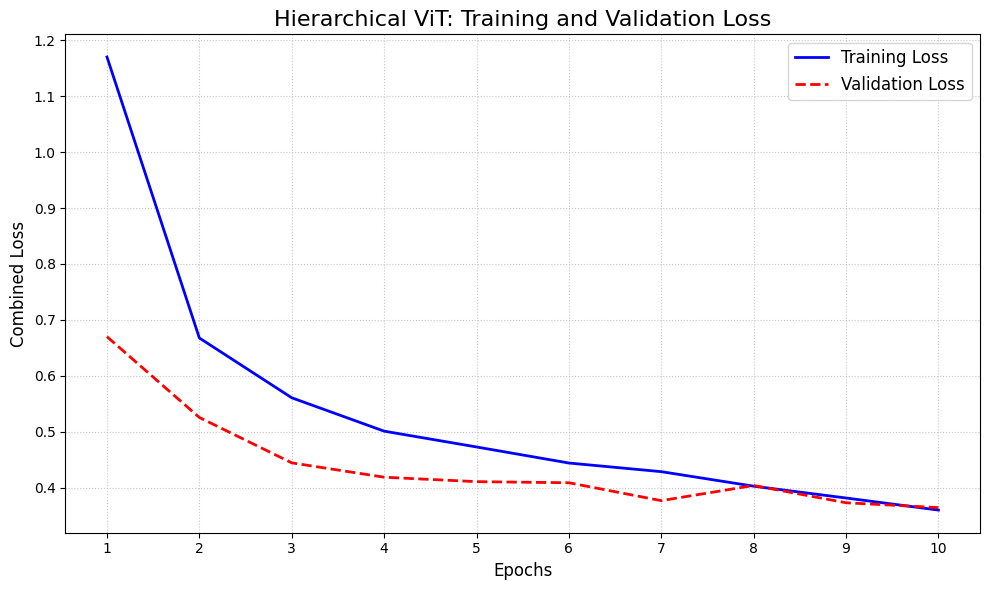

In [53]:
def plot_training_history(history):
    """Plots the training and validation loss curves.

    Args:
        history (dict): A dictionary containing 'train_loss' and 'val_loss' lists,
                        returned by the training loop.

    Returns:
        None
    """
    # Extracting the loss values from the history dictionary
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    
    # Creating a sequence of epoch numbers for the x axis
    epochs = range(1, len(train_loss) + 1)
    
    # Initializing the plot figure
    plt.figure(figsize=(10, 6))
    
    # Plotting both the training and validation losses
    plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    
    # Adding labels, title, and a grid
    plt.title('Hierarchical ViT: Training and Validation Loss', fontsize=16)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Combined Loss', fontsize=12)
    
    # Forcing the x axis to display integer ticks for epochs
    plt.xticks(epochs)
    
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Display the final plot
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [54]:
def save_trained_model(model, filepath):
    """Saves the learned weights of the model to a file."""
    
    # Extracting the dictionary of weights
    weights_dictionary = model.state_dict()
    
    # Saving the dictionary to the specified file path
    torch.save(weights_dictionary, filepath)
    
    print(f"Success: Model weights securely saved to '{filepath}'")

# Ensure the 'models' directory exists before saving
os.makedirs("models", exist_ok=True)
save_trained_model(model, filepath="models/best_zooplankton_model_v2.pth")

Success: Model weights securely saved to 'models/best_zooplankton_model_v2.pth'


In [29]:
def load_trained_model(filepath, device):
    """Creates a blank model and loads the saved weights into it."""
    
    # Instantiating the exact same class architecture the model was trained with
    model = HierarchicalZooplanktonViT(pretrained=False)
    
    # Loading the dictionary of weights from our file
    saved_weights = torch.load(filepath, map_location=device, weights_only=True)
    
    # Assigning weights into our blank model
    model.load_state_dict(saved_weights)
    
    # Moving the model to your active device
    model = model.to(device)
    
    # Locking the model into evaluation mode for inference
    model.eval()
    
    print(f"Success: Model weights loaded from '{filepath}'")
    
    return model

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = load_trained_model("models/best_zooplankton_model_v2.pth", device)

Success: Model weights loaded from 'models/best_zooplankton_model_v2.pth'


In [30]:
# Evaluating the Model

# Valid Level 0 mapping
VALID_L0_MAPPING = {
    "ROOT": [0, 1]
}

# Valid Level 1 mapping
VALID_L1_MAPPING = {
    1: [0, 1, 2],
    0: [3, 4, 5, 6]
}

# Valid Level 2 mapping
VALID_L2_MAPPING = {
    0: [0, 1],
    2: [2, 3, 4, 5]
}

In [37]:
# def predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2):
#     """Predicts the hierarchy using identical logic blocks for every single level."""
#     model.eval()
    
#     with torch.no_grad():
#         logits = model(images)
#         batch_size = images.shape[0]
        
#         pred_l0_list = []
#         pred_l1_list = []
#         pred_l2_list = []
        
#         for i in range(batch_size):
            

#             # Level 0 Prediction
#             l0_logits = logits['L0'][i].clone()
#             parent_l0 = "ROOT"  # Level 0's fake parent
            
#             if parent_l0 in map_l0:
#                 valid_l0_classes = map_l0[parent_l0]
#                 for class_idx in range(len(l0_logits)):
#                     if class_idx not in valid_l0_classes:
#                         l0_logits[class_idx] = float('-inf')
#                 l0_pred = torch.argmax(l0_logits).item()
#             else:
#                 l0_pred = -1
                
#             pred_l0_list.append(l0_pred)
            

#             # Level 1 Prediction
#             l1_logits = logits['L1'][i].clone()
#             parent_l1 = l0_pred  # Level 1's parent is the Level 0 prediction
            
#             if parent_l1 in map_l1:
#                 valid_l1_classes = map_l1[parent_l1]
#                 for class_idx in range(len(l1_logits)):
#                     if class_idx not in valid_l1_classes:
#                         l1_logits[class_idx] = float('-inf')
#                 l1_pred = torch.argmax(l1_logits).item()
#             else:
#                 l1_pred = -1
                
#             pred_l1_list.append(l1_pred)
            

#             # Level 2 Prediction
#             l2_logits = logits['L2'][i].clone()
#             parent_l2 = l1_pred  # Level 2's parent is the Level 1 prediction
            
#             if parent_l2 in map_l2:
#                 valid_l2_classes = map_l2[parent_l2]
#                 for class_idx in range(len(l2_logits)):
#                     if class_idx not in valid_l2_classes:
#                         l2_logits[class_idx] = float('-inf')
#                 l2_pred = torch.argmax(l2_logits).item()
#             else:
#                 l2_pred = -1
                
#             pred_l2_list.append(l2_pred)

#         # Converting to tensors
#         device = images.device
#         pred_l0_tensor = torch.tensor(pred_l0_list, device=device)
#         pred_l1_tensor = torch.tensor(pred_l1_list, device=device)
#         pred_l2_tensor = torch.tensor(pred_l2_list, device=device)
        
#         return pred_l0_tensor, pred_l1_tensor, pred_l2_tensor

In [38]:

# def evaluate_hierarchical_model(model, test_loader, device, map_l0, map_l1, map_l2):
#     """Evaluates the model on the test set using explicit, level-by-level scoring."""
#     model.eval()
    

#     total_samples = 0
#     correct_l0 = 0
#     correct_l1 = 0
#     correct_l2 = 0
#     strict_correct = 0
    
#     with torch.no_grad():
#         for images, targets in tqdm(test_loader, desc="Evaluating Test Set"):
#             images = images.to(device)
            

#             t_l0 = targets['L0'].to(device)
#             t_l1 = targets['L1'].to(device)
#             t_l2 = targets['L2'].to(device)
            

#             p_l0, p_l1, p_l2 = predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2)
            

#             batch_size = images.size(0)
#             total_samples += batch_size
            
 
#             # SCORING Level 0
#             correct_l0 += (p_l0 == t_l0).sum().item()
            

#             # SCORING Level 1
#             correct_l1 += (p_l1 == t_l1).sum().item()
            

#             # SCORING Level 2
#             correct_l2 += (p_l2 == t_l2).sum().item()
            

#             # SCORING Strict Path Accuracy
#             # The model only gets a point if all three levels are perfectly correct

#             path_correct = (p_l0 == t_l0) & (p_l1 == t_l1) & (p_l2 == t_l2)
#             strict_correct += path_correct.sum().item()

#     # Calculating final percentages
#     acc_l0 = (correct_l0 / total_samples) * 100
#     acc_l1 = (correct_l1 / total_samples) * 100
#     acc_l2 = (correct_l2 / total_samples) * 100
#     acc_strict = (strict_correct / total_samples) * 100
    

#     print("\n" + "="*30)
#     print("FINAL TEST SET EVALUATION")
#     print("="*30)
#     print(f"Level 0 Accuracy: {acc_l0:.2f}%")
#     print(f"Level 1 Accuracy: {acc_l1:.2f}%")
#     print(f"Level 2 Accuracy: {acc_l2:.2f}%")
#     print("-" * 30)
#     print(f"Strict Path Accuracy: {acc_strict:.2f}%")
#     print("="*30)
    
#     return acc_strict


In [39]:
# evaluate_hierarchical_model(
#     model=model, 
#     test_loader=test_loader, 
#     device=device, 
#     map_l0=VALID_L0_MAPPING, 
#     map_l1=VALID_L1_MAPPING, 
#     map_l2=VALID_L2_MAPPING
# )

In [40]:
# import torch
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, classification_report
# from tqdm import tqdm

# def evaluate_pipeline_with_masked(model, test_loader, device, map_l0, map_l1, map_l2):
#     """Evaluates the pipeline and plots matrices INCLUDING the -1 targets."""
#     model.eval()
    
#     # Lists to store targets and predictions
#     all_t_l0, all_p_l0 = [], []
#     all_t_l1, all_p_l1 = [], []
#     all_t_l2, all_p_l2 = [], []
    
#     with torch.no_grad():
#         for images, targets in tqdm(test_loader, desc="Evaluating Pipeline"):
#             images = images.to(device)
            
#             t_l0 = targets['L0'].to(device)
#             t_l1 = targets['L1'].to(device)
#             t_l2 = targets['L2'].to(device)
            
#             # Use your custom pipeline function
#             p_l0, p_l1, p_l2 = predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2)
            
#             # Store ALL results, including the -1s
#             all_t_l0.extend(t_l0.cpu().numpy())
#             all_p_l0.extend(p_l0.cpu().numpy())
            
#             all_t_l1.extend(t_l1.cpu().numpy())
#             all_p_l1.extend(p_l1.cpu().numpy())
            
#             all_t_l2.extend(t_l2.cpu().numpy())
#             all_p_l2.extend(p_l2.cpu().numpy())

#     # Helper function to print report and plot matrix
#     def print_report_and_matrix(true_labels, predicted_labels, class_names, valid_integers, title):
#         print(f"\n{'='*50}")
#         print(f"{title} PERFORMANCE REPORT")
#         print(f"{'='*50}")
        
#         # 1. Print the Classification Report
#         report = classification_report(
#             true_labels, 
#             predicted_labels, 
#             labels=valid_integers,
#             target_names=class_names, 
#             zero_division=0
#         )
#         print(report)
        
#         # 2. Plot the Confusion Matrix
#         # We MUST pass the valid_integers list to keep the -1 at the very end
#         cm = confusion_matrix(true_labels, predicted_labels, labels=valid_integers)
        
#         plt.figure(figsize=(10, 8))
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#                     xticklabels=class_names, yticklabels=class_names)
        
#         plt.title(f'Confusion Matrix: {title}', fontsize=16)
#         plt.xlabel('Pipeline Predicted Label', fontsize=12)
#         plt.ylabel('True Label', fontsize=12)
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.show()

#     # Define the names AND the explicit integer order
#     l0_names = ["Not-Zooplankton", "Zooplankton"]
#     l0_ints = [0, 1]
    
#     l1_names = ["Cladocera", "Rotifer", "Copepoda", "Bubble", "Exoskeleton", "Fiber", "Plant_Matter", "Masked (-1)"]
#     l1_ints = [0, 1, 2, 3, 4, 5, 6, -1]
    
#     l2_names = ["Bosmina", "Daphnia", "Nauplius", "Cyclopoid", "Harpacticoid", "Calanoid", "Masked (-1)"]
#     l2_ints = [0, 1, 2, 3, 4, 5, -1]

#     # Execute for all three levels
#     print_report_and_matrix(all_t_l0, all_p_l0, l0_names, l0_ints, "PIPELINE: LEVEL 0")
#     print_report_and_matrix(all_t_l1, all_p_l1, l1_names, l1_ints, "PIPELINE: LEVEL 1")
#     print_report_and_matrix(all_t_l2, all_p_l2, l2_names, l2_ints, "PIPELINE: LEVEL 2")

# # Run the evaluation
# evaluate_pipeline_with_masked(model, test_loader, device, VALID_L0_MAPPING, VALID_L1_MAPPING, VALID_L2_MAPPING)

In [41]:
import torch.nn.functional as F

def predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2):
    """Predicts the hierarchy and returns both classes and probabilities."""
    model.eval()
    
    with torch.no_grad():
        logits = model(images)
        batch_size = images.shape[0]
        
        # Calculate probabilities from logits using Softmax
        probs_l0 = F.softmax(logits['L0'], dim=1)
        probs_l1 = F.softmax(logits['L1'], dim=1)
        probs_l2 = F.softmax(logits['L2'], dim=1)
        
        pred_l0_list, prob_l0_list = [], []
        pred_l1_list, prob_l1_list = [], []
        pred_l2_list, prob_l2_list = [], []
        
        for i in range(batch_size):
            
            # Level 0 Prediction
            l0_logits_clone = logits['L0'][i].clone()
            parent_l0 = "ROOT"
            
            if parent_l0 in map_l0:
                valid_l0_classes = map_l0[parent_l0]
                for class_idx in range(len(l0_logits_clone)):
                    if class_idx not in valid_l0_classes:
                        l0_logits_clone[class_idx] = float('-inf')
                
                l0_pred = torch.argmax(l0_logits_clone).item()
                # Get the softmax probability for the winning class
                l0_prob = probs_l0[i][l0_pred].item() 
            else:
                l0_pred = -1
                l0_prob = 1.0 # 100% confident it's invalid
                
            pred_l0_list.append(l0_pred)
            prob_l0_list.append(l0_prob)
            

            # Level 1 Prediction
            l1_logits_clone = logits['L1'][i].clone()
            parent_l1 = l0_pred
            
            if parent_l1 in map_l1:
                valid_l1_classes = map_l1[parent_l1]
                for class_idx in range(len(l1_logits_clone)):
                    if class_idx not in valid_l1_classes:
                        l1_logits_clone[class_idx] = float('-inf')
                
                l1_pred = torch.argmax(l1_logits_clone).item()
                l1_prob = probs_l1[i][l1_pred].item()
            else:
                l1_pred = -1
                l1_prob = 1.0 # 100% confident it's invalid due to L0 mask
                
            pred_l1_list.append(l1_pred)
            prob_l1_list.append(l1_prob)
            

            # Level 2 Prediction
            l2_logits_clone = logits['L2'][i].clone()
            parent_l2 = l1_pred
            
            if parent_l2 in map_l2:
                valid_l2_classes = map_l2[parent_l2]
                for class_idx in range(len(l2_logits_clone)):
                    if class_idx not in valid_l2_classes:
                        l2_logits_clone[class_idx] = float('-inf')
                
                l2_pred = torch.argmax(l2_logits_clone).item()
                l2_prob = probs_l2[i][l2_pred].item()
            else:
                l2_pred = -1
                # If L1 predicted a terminal node, L2 is definitely -1
                l2_prob = 1.0 
                
            pred_l2_list.append(l2_pred)
            prob_l2_list.append(l2_prob)

        # Converting to tensors
        device = images.device
        pred_l0_tensor = torch.tensor(pred_l0_list, device=device)
        prob_l0_tensor = torch.tensor(prob_l0_list, device=device)
        
        pred_l1_tensor = torch.tensor(pred_l1_list, device=device)
        prob_l1_tensor = torch.tensor(prob_l1_list, device=device)
        
        pred_l2_tensor = torch.tensor(pred_l2_list, device=device)
        prob_l2_tensor = torch.tensor(prob_l2_list, device=device)
        
        # Return predictions and their corresponding confidence scores
        return (pred_l0_tensor, prob_l0_tensor), (pred_l1_tensor, prob_l1_tensor), (pred_l2_tensor, prob_l2_tensor)

In [42]:
def evaluate_hierarchical_model(model, test_loader, device, map_l0, map_l1, map_l2):
    """Evaluates the model on the test set using explicit, level-by-level scoring."""
    model.eval()
    
    total_samples = 0
    correct_l0 = 0
    correct_l1 = 0
    correct_l2 = 0
    strict_correct = 0
    
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Evaluating Test Set"):
            images = images.to(device)
            
            t_l0 = targets['L0'].to(device)
            t_l1 = targets['L1'].to(device)
            t_l2 = targets['L2'].to(device)
            
            # UNPACK THE TUPLES: Predictions and Probabilities
            (p_l0, prob_l0), (p_l1, prob_l1), (p_l2, prob_l2) = predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2)
            
            batch_size = images.size(0)
            total_samples += batch_size
            
            # SCORING (Probabilities are not used for strict accuracy, just tracking)
            correct_l0 += (p_l0 == t_l0).sum().item()
            correct_l1 += (p_l1 == t_l1).sum().item()
            correct_l2 += (p_l2 == t_l2).sum().item()
            
            path_correct = (p_l0 == t_l0) & (p_l1 == t_l1) & (p_l2 == t_l2)
            strict_correct += path_correct.sum().item()

    acc_l0 = (correct_l0 / total_samples) * 100
    acc_l1 = (correct_l1 / total_samples) * 100
    acc_l2 = (correct_l2 / total_samples) * 100
    acc_strict = (strict_correct / total_samples) * 100
    
    print("\n" + "="*30)
    print("FINAL TEST SET EVALUATION")
    print("="*30)
    print(f"Level 0 Accuracy: {acc_l0:.2f}%")
    print(f"Level 1 Accuracy: {acc_l1:.2f}%")
    print(f"Level 2 Accuracy: {acc_l2:.2f}%")
    print("-" * 30)
    print(f"Strict Path Accuracy: {acc_strict:.2f}%")
    print("="*30)
    
    return acc_strict

In [43]:
evaluate_hierarchical_model(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    map_l0=VALID_L0_MAPPING, 
    map_l1=VALID_L1_MAPPING, 
    map_l2=VALID_L2_MAPPING
)

Evaluating Test Set: 100%|██████████████████████| 134/134 [01:23<00:00,  1.61it/s]


FINAL TEST SET EVALUATION
Level 0 Accuracy: 99.63%
Level 1 Accuracy: 96.34%
Level 2 Accuracy: 92.53%
------------------------------
Strict Path Accuracy: 91.74%


91.73669467787114

In [46]:
def evaluate_pipeline_with_masked(model, test_loader, device, map_l0, map_l1, map_l2):
    """Evaluates the pipeline and plots matrices INCLUDING the -1 targets."""
    model.eval()
    
    all_t_l0, all_p_l0, all_prob_l0 = [], [], []
    all_t_l1, all_p_l1, all_prob_l1 = [], [], []
    all_t_l2, all_p_l2, all_prob_l2 = [], [], []
    
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc="Evaluating Pipeline"):
            images = images.to(device)
            
            t_l0 = targets['L0'].to(device)
            t_l1 = targets['L1'].to(device)
            t_l2 = targets['L2'].to(device)
            
            # UNPACK THE TUPLES
            (p_l0, prob_l0), (p_l1, prob_l1), (p_l2, prob_l2) = predict_strict_hierarchy(model, images, map_l0, map_l1, map_l2)
            
            all_t_l0.extend(t_l0.cpu().numpy())
            all_p_l0.extend(p_l0.cpu().numpy())
            all_prob_l0.extend(prob_l0.cpu().numpy()) # Store probabilities
            
            all_t_l1.extend(t_l1.cpu().numpy())
            all_p_l1.extend(p_l1.cpu().numpy())
            all_prob_l1.extend(prob_l1.cpu().numpy()) # Store probabilities
            
            all_t_l2.extend(t_l2.cpu().numpy())
            all_p_l2.extend(p_l2.cpu().numpy())
            all_prob_l2.extend(prob_l2.cpu().numpy()) # Store probabilities

    def print_report_and_matrix(true_labels, predicted_labels, class_names, valid_integers, title):
        print(f"\n{'='*50}")
        print(f"{title} PERFORMANCE REPORT")
        print(f"{'='*50}")
        
        report = classification_report(
            true_labels, predicted_labels, labels=valid_integers, target_names=class_names, zero_division=0
        )
        print(report)
        
        cm = confusion_matrix(true_labels, predicted_labels, labels=valid_integers)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix: {title}', fontsize=16)
        plt.xlabel('Pipeline Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    l0_names = ["Not-Zooplankton", "Zooplankton"]
    l0_ints = [0, 1]
    
    l1_names = ["Cladocera", "Rotifer", "Copepoda", "Bubble", "Exoskeleton", "Fiber", "Plant_Matter", "Masked (-1)"]
    l1_ints = [0, 1, 2, 3, 4, 5, 6, -1]
    
    l2_names = ["Bosmina", "Daphnia", "Nauplius", "Cyclopoid", "Harpacticoid", "Calanoid", "Masked (-1)"]
    l2_ints = [0, 1, 2, 3, 4, 5, -1]

    print_report_and_matrix(all_t_l0, all_p_l0, l0_names, l0_ints, "PIPELINE: LEVEL 0")
    print_report_and_matrix(all_t_l1, all_p_l1, l1_names, l1_ints, "PIPELINE: LEVEL 1")
    print_report_and_matrix(all_t_l2, all_p_l2, l2_names, l2_ints, "PIPELINE: LEVEL 2")

    # You now have access to all_prob_l0, all_prob_l1, all_prob_l2 if you want to analyze confidence!
    # return (all_t_l0, all_p_l0, all_prob_l0), (all_t_l1, all_p_l1, all_prob_l1), (all_t_l2, all_p_l2, all_prob_l2)

Evaluating Pipeline: 100%|██████████████████████| 134/134 [01:23<00:00,  1.60it/s]


PIPELINE: LEVEL 0 PERFORMANCE REPORT
                 precision    recall  f1-score   support

Not-Zooplankton       1.00      1.00      1.00      1999
    Zooplankton       1.00      1.00      1.00      2285

       accuracy                           1.00      4284
      macro avg       1.00      1.00      1.00      4284
   weighted avg       1.00      1.00      1.00      4284



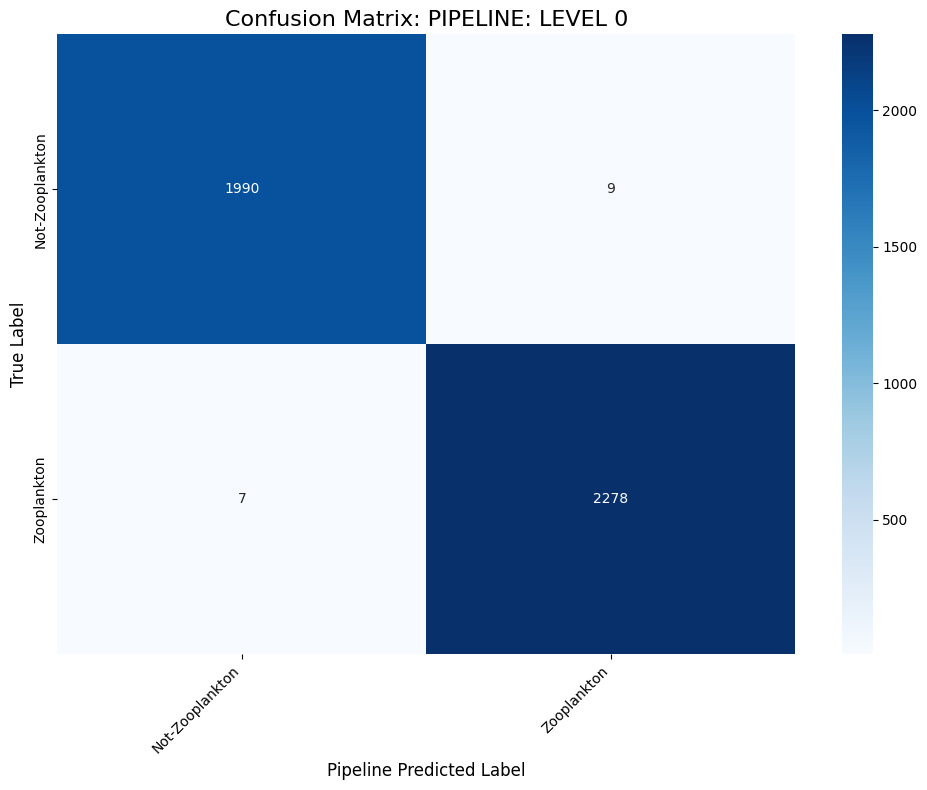


PIPELINE: LEVEL 1 PERFORMANCE REPORT
              precision    recall  f1-score   support

   Cladocera       0.96      0.93      0.94       880
     Rotifer       0.86      0.97      0.91       325
    Copepoda       0.96      0.95      0.95      1080
      Bubble       1.00      0.25      0.40         4
 Exoskeleton       0.93      0.95      0.94       183
       Fiber       1.00      0.99      0.99      1736
Plant_Matter       0.90      0.97      0.94        76
 Masked (-1)       0.00      0.00      0.00         0

    accuracy                           0.96      4284
   macro avg       0.83      0.75      0.76      4284
weighted avg       0.96      0.96      0.96      4284



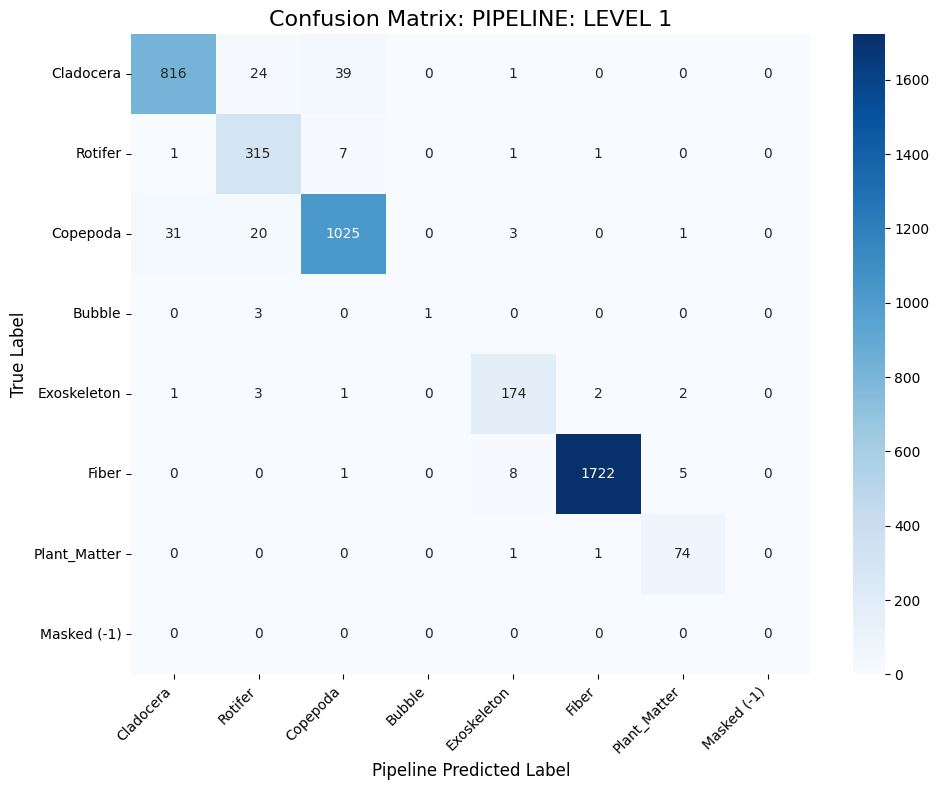


PIPELINE: LEVEL 2 PERFORMANCE REPORT
              precision    recall  f1-score   support

     Bosmina       0.80      0.90      0.85       417
     Daphnia       0.91      0.99      0.94       347
    Nauplius       0.91      0.93      0.92       752
   Cyclopoid       0.78      0.87      0.82       186
Harpacticoid       1.00      1.00      1.00         1
    Calanoid       0.64      0.88      0.74        72
 Masked (-1)       0.98      0.92      0.95      2509

    accuracy                           0.93      4284
   macro avg       0.86      0.93      0.89      4284
weighted avg       0.93      0.93      0.93      4284



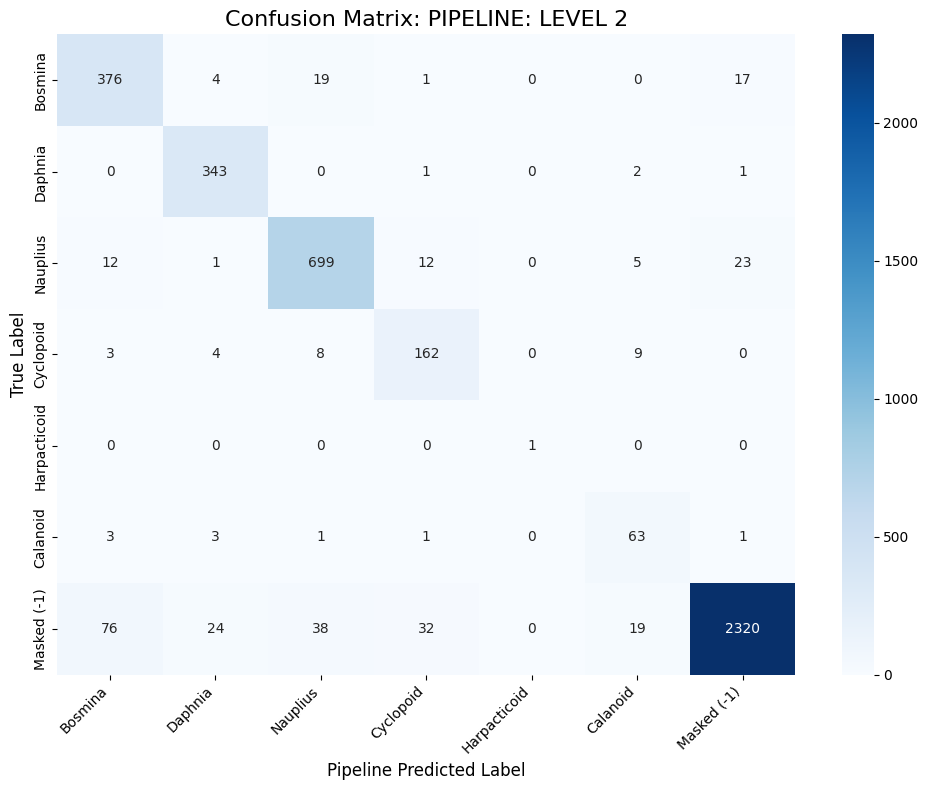

In [47]:
# Run the evaluation
evaluate_pipeline_with_masked(model, test_loader, device, VALID_L0_MAPPING, VALID_L1_MAPPING, VALID_L2_MAPPING)

In [ ]:
REVERSE_L0_MAP = {
    0: "Not-Zooplankton", 
    1: "Zooplankton", 
    -1: "Unknown/Invalid"
}

REVERSE_L1_MAP = {
    0: "Cladocera", 
    1: "Rotifer", 
    2: "Copepoda", 
    3: "Bubble", 
    4: "Exoskeleton", 
    5: "Fiber", 
    6: "Plant_Matter", 
    -1: "Masked (Terminal Parent)"
}

REVERSE_L2_MAP = {
    0: "Bosmina", 
    1: "Daphnia", 
    2: "Nauplius", 
    3: "Cyclopoid", 
    4: "Harpacticoid", 
    5: "Calanoid", 
    -1: "Masked (Terminal Parent)"
}

In [66]:
import os
from PIL import Image
import torchvision.transforms as transforms

# Standard inference transform (must match validation transforms exactly)
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def infer_single_image(image_path, model, device, map_l0, map_l1, map_l2):
    """Loads a single image, runs strict top-down inference, and returns readable labels."""
    
    # 1. Open image and convert to RGB (to ensure 3 channels)
    image = Image.open(image_path).convert('RGB')
    
    # 2. Apply transforms and add the required batch dimension using unsqueeze(0)
    # This turns shape [3, 224, 224] into [1, 3, 224, 224]
    input_tensor = inference_transform(image).unsqueeze(0).to(device)
    
    # 3. Run our custom pipeline function
    (p_l0, prob_l0), (p_l1, prob_l1), (p_l2, prob_l2) = predict_strict_hierarchy(
        model, input_tensor, map_l0, map_l1, map_l2
    )
    
    # 4. Extract integer values from the tensors
    l0_idx = p_l0.item()
    l1_idx = p_l1.item()
    l2_idx = p_l2.item()
    
    # 5. Translate integers back to string labels and format results
    results = {
        'Level 0': {'Class': REVERSE_L0_MAP.get(l0_idx, "Unknown"), 'Confidence': prob_l0.item()},
        'Level 1': {'Class': REVERSE_L1_MAP.get(l1_idx, "Unknown"), 'Confidence': prob_l1.item()},
        'Level 2': {'Class': REVERSE_L2_MAP.get(l2_idx, "Unknown"), 'Confidence': prob_l2.item()}
    }
    
    return results

def run_inference_on_folder(folder_path, model, device):
    """Iterates through a folder of images and prints the hierarchical predictions."""
    
    print(f"Running inference on images in: '{folder_path}'\n")
    print("=" * 60)
    
    # Check if the directory exists to prevent crash
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    # Loop through all files in the directory
    for filename in os.listdir(folder_path):
        
        # Only process valid image formats
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            img_path = os.path.join(folder_path, filename)
            
            # Get the prediction dictionary
            predictions = infer_single_image(
                img_path, model, device, 
                VALID_L0_MAPPING, VALID_L1_MAPPING, VALID_L2_MAPPING
            )
            
            # Print the formatted output
            print(f"Image: {filename}")
            print(f"  Level 0: {predictions['Level 0']['Class']:<30} | Confidence: {predictions['Level 0']['Confidence']:.2%}")
            print(f"  Level 1: {predictions['Level 1']['Class']:<30} | Confidence: {predictions['Level 1']['Confidence']:.2%}")
            print(f"  Level 2: {predictions['Level 2']['Class']:<30} | Confidence: {predictions['Level 2']['Confidence']:.2%}")
            print("-" * 60)

In [67]:
INFERENCE_FOLDER = "data/Inference_Test_Images"

run_inference_on_folder(INFERENCE_FOLDER, model, device)

Running inference on images in: 'data/Inference_Test_Images'

Image: me.jpg
  Level 0: Not-Zooplankton                | Confidence: 95.90%
  Level 1: Exoskeleton                    | Confidence: 89.73%
  Level 2: Terminal Parent or Unknown     | Confidence: 100.00%
------------------------------------------------------------
Image: fiber_hairlike_test.tif
  Level 0: Not-Zooplankton                | Confidence: 100.00%
  Level 1: Fiber                          | Confidence: 99.99%
  Level 2: Terminal Parent or Unknown     | Confidence: 100.00%
------------------------------------------------------------
Image: fiber_squiggly_test.tif
  Level 0: Not-Zooplankton                | Confidence: 100.00%
  Level 1: Fiber                          | Confidence: 99.99%
  Level 2: Terminal Parent or Unknown     | Confidence: 100.00%
------------------------------------------------------------
Image: bosmina_test.tif
  Level 0: Zooplankton                    | Confidence: 100.00%
  Level 1: Cladocer